# Alpha 顶点动能：保存模型的独立评估

**功能**：加载 EnergyLoss_output/EnergyLossMLP.pt，对 Processd_test.root 预测 alpha 顶点总动能并与能量和基线比较。
**方法**：复用模型的特征顺序和训练集归一化参数，float64、eval/no_grad 推理，再恢复 MeV。
**注意事项**：不重新拟合归一化，不训练网络；SSD 位置与顶点均为模拟真值。常量列的安全缩放由训练 Notebook 保存，预测端原样复用。完整模型只加载自己生成的可信文件，所有误差指标使用全部事件，直方图范围外事件仍计入指标。


In [1]:
from pathlib import Path

import numpy as np
import torch
import uproot
import matplotlib.pyplot as plt

ROOT_PATH = Path("Processd_test.root")
TREE_NAME = "tree"
MODEL_PATH = Path("EnergyLoss_output/EnergyLossMLP.pt")
TARGET_NAME = "KinematicsAtVertex"
DTYPE = torch.float64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:
saved = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)

model = saved["model"].to(device=device, dtype=DTYPE)
model.eval()

FEATURE_NAMES = saved["feature_names"]
x_mean = np.asarray(saved["x_mean"], dtype=np.float64)
x_std = np.asarray(saved["x_std"], dtype=np.float64)
y_mean = np.asarray(saved["y_mean"], dtype=np.float64)
y_std = np.asarray(saved["y_std"], dtype=np.float64)

print(model)
print("Loaded:", MODEL_PATH.resolve())


Sequential(
  (0): Linear(in_features=13, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=1, bias=True)
)
Loaded: /Users/yemingxin/ROOT_Exercise/MachineLearning/EnergyLoss/EnergyLoss_output/EnergyLossMLP.pt


In [3]:
branches = FEATURE_NAMES + [TARGET_NAME]

with uproot.open(ROOT_PATH) as root_file:
    tree = root_file[TREE_NAME]
    missing = [name for name in branches if name not in tree.keys()]
    if missing:
        raise KeyError(f"Missing branches: {missing}")
    arrays = tree.arrays(branches, library="np", how=dict)

X = np.column_stack([arrays[name] for name in FEATURE_NAMES]).astype(np.float64)
y = np.asarray(arrays[TARGET_NAME], dtype=np.float64).reshape(-1, 1)

if not np.all(np.isfinite(X)) or not np.all(np.isfinite(y)):
    raise ValueError("Input contains NaN/Inf.")
if np.any(X == -999.0) or np.any(y == -999.0):
    raise ValueError("Input contains -999.")

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)


X: (13671, 13) float64
y: (13671, 1) float64


进行预测

In [4]:
X_scaled = (X - x_mean) / x_std
X_tensor = torch.from_numpy(X_scaled).to(device=device, dtype=DTYPE)

with torch.no_grad():
    pred_scaled = model(X_tensor).cpu().numpy()

pred = pred_scaled * y_std + y_mean
residual = pred - y

print("Predicted events:", len(pred))
print("entry     truth (MeV)    prediction (MeV)    residual (MeV)")
for i in range(min(10, len(pred))):
    print(f"{i:5d} {y[i, 0]:15.6f} {pred[i, 0]:19.6f} {residual[i, 0]:17.6f}")


Predicted events: 13671
entry     truth (MeV)    prediction (MeV)    residual (MeV)
    0      663.872602          664.677992          0.805390
    1      636.656973          637.675971          1.018998
    2      748.644885          748.269017         -0.375868
    3      712.535459          712.402792         -0.132667
    4      714.367546          713.209522         -1.158024
    5      664.418156          666.516549          2.098393
    6      747.828852          747.701404         -0.127448
    7      689.301590          690.848035          1.546445
    8      677.793282          678.286855          0.493573
    9      644.000844          643.737237         -0.263606


Test events: 13671
MSE_MeV2             MLP=4.99555  energy-sum baseline=886.461
RMSE_MeV             MLP=2.23507  energy-sum baseline=29.7735
MAE_MeV              MLP=1.35523  energy-sum baseline=22.9285
R2                   MLP=0.996776  energy-sum baseline=0.42796
Bias_MeV             MLP=-0.000986969  energy-sum baseline=-22.9204
ResidualStd_MeV      MLP=2.23507  energy-sum baseline=19.0031


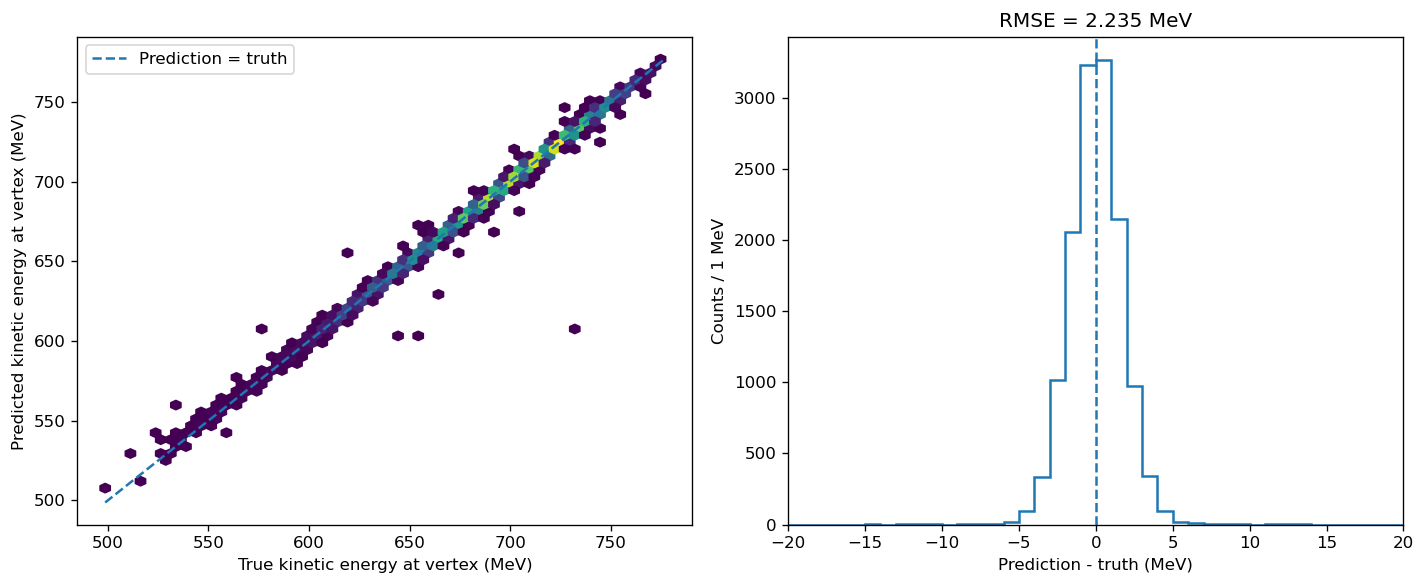

In [5]:
def regression_metrics(truth, prediction):
    difference = prediction - truth
    mse = float(np.mean(difference ** 2))
    ss_tot = float(np.sum((truth - truth.mean()) ** 2))
    r2 = 1.0 - float(np.sum(difference ** 2)) / ss_tot if ss_tot > 0 else np.nan

    return {
        "MSE_MeV2": mse,
        "RMSE_MeV": float(np.sqrt(mse)),
        "MAE_MeV": float(np.mean(np.abs(difference))),
        "R2": r2,
        "Bias_MeV": float(difference.mean()),
        "ResidualStd_MeV": float(difference.std()),
    }

metrics = regression_metrics(y, pred)
energy_sum = X[:, :2].sum(axis=1, keepdims=True)
baseline_metrics = regression_metrics(y, energy_sum)

print(f"Test events: {len(y)}")
for name in metrics:
    print(f"{name:20s} MLP={metrics[name]:.6g}  energy-sum baseline={baseline_metrics[name]:.6g}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hexbin(y[:, 0], pred[:, 0], gridsize=55, mincnt=1)
lo = min(y.min(), pred.min())
hi = max(y.max(), pred.max())
axes[0].plot([lo, hi], [lo, hi], "--", label="Prediction = truth")
axes[0].set_xlabel("True kinetic energy at vertex (MeV)")
axes[0].set_ylabel("Predicted kinetic energy at vertex (MeV)")
axes[0].legend()

bins = np.arange(-20.0, 21.0, 1.0)
axes[1].hist(residual[:, 0], bins=bins, histtype="step", linewidth=1.5)
axes[1].axvline(0.0, linestyle="--")
axes[1].set_xlim(-20, 20)
axes[1].set_xlabel("Prediction - truth (MeV)")
axes[1].set_ylabel("Counts / 1 MeV")
axes[1].set_title(f"RMSE = {metrics['RMSE_MeV']:.3f} MeV")

fig.tight_layout()
plt.show()
